<a href="https://colab.research.google.com/github/vedashri924/traffic/blob/main/traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the traffic data
df = pd.read_csv('/content/traffic.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


Now, let's get a summary of the DataFrame, including data types and non-null values, to identify any immediate cleaning needs.

In [2]:
# Display information about the DataFrame to check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216999 entries, 0 to 216998
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    216999 non-null  object
 1   date     216999 non-null  object
 2   country  216987 non-null  object
 3   city     216987 non-null  object
 4   artist   216962 non-null  object
 5   album    216993 non-null  object
 6   track    216993 non-null  object
 7   isrc     210239 non-null  object
 8   linkid   216998 non-null  object
dtypes: object(9)
memory usage: 14.9+ MB


First, let's convert the `date` column to a datetime format to facilitate time-based analysis. Then, I will address the missing values in the dataset.

In [5]:
# Convert 'date' column to datetime objects
df['date'] = pd.to_datetime(df['date'])

# Display the DataFrame info again to confirm the data type change
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 216998 entries, 0 to 216997
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    216998 non-null  object        
 1   date     216998 non-null  datetime64[ns]
 2   country  216998 non-null  object        
 3   city     216998 non-null  object        
 4   artist   216998 non-null  object        
 5   album    216998 non-null  object        
 6   track    216998 non-null  object        
 7   isrc     216998 non-null  object        
 8   linkid   216998 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 16.6+ MB


Let's check for missing values across all columns and then fill the missing categorical values with 'Unknown'.

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values before handling:\n", missing_values)

# Fill missing categorical values with 'Unknown'
for col in ['country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Verify that missing values have been handled
print("\nMissing values after handling:\n", df.isnull().sum())

Missing values before handling:
 event         0
date          0
country      12
city         12
artist       37
album         6
track         6
isrc       6760
linkid        1
dtype: int64

Missing values after handling:
 event      0
date       0
country    0
city       0
artist     0
album      0
track      0
isrc       0
linkid     0
dtype: int64


## Compute Metrics: Sessions, Users, Bounce Rate

We will define a 'session' and a 'user' based on the unique `linkid` values. A bounce is considered a session with only one event. Note that 'Average Session Duration' cannot be accurately calculated as the dataset only contains the `date` but no `time` information for each event.

In [6]:
# Calculate total sessions and unique users
total_sessions = df['linkid'].nunique()
total_users = df['linkid'].nunique() # Assuming each linkid represents a unique user session

print(f"Total Sessions: {total_sessions}")
print(f"Total Users (based on unique linkid): {total_users}")

# Calculate bounce rate
# Group by linkid and count events per session
session_event_counts = df.groupby('linkid').size()

# Identify bounced sessions (sessions with only one event)
bounced_sessions_count = (session_event_counts == 1).sum()

# Calculate bounce rate
bounce_rate = (bounced_sessions_count / total_sessions) * 100

print(f"Bounced Sessions: {bounced_sessions_count}")
print(f"Bounce Rate: {bounce_rate:.2f}%")

Total Sessions: 3741
Total Users (based on unique linkid): 3741
Bounced Sessions: 1318
Bounce Rate: 35.23%


## Visualize User Flows: Top Entry and Exit Pages

To understand user behavior, we'll identify the top entry and exit pages. The entry page for each session is the first page visited, and the exit page is the last.

Top 10 Entry Pages:
track
Baby Shark                               5
Get Back                                 4
Okay                                     4
Happy Birthday                           4
Freestyle                                4
Heat Waves                               4
Outside                                  3
Hats Off (feat. Travis Scott)            3
Switching Lanes (feat. Playboi Carti)    3
Pop It (feat. Megan Thee Stallion)       3
Name: count, dtype: int64

Top 10 Exit Pages:
track
Baby Shark                               5
Get Back                                 4
Okay                                     4
Happy Birthday                           4
Freestyle                                4
Heat Waves                               4
Outside                                  3
Hats Off (feat. Travis Scott)            3
Switching Lanes (feat. Playboi Carti)    3
Pop It (feat. Megan Thee Stallion)       3
Name: count, dtype: int64


/tmp/ipykernel_6682/409146126.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=entry_pages.index, y=entry_pages.values, palette='viridis')


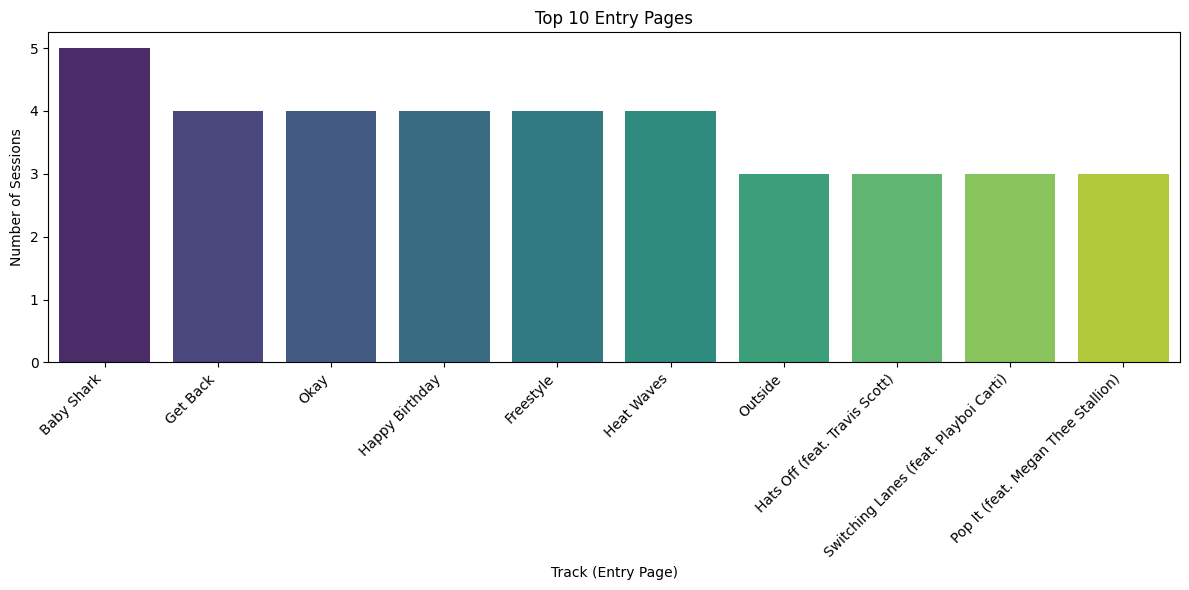

/tmp/ipykernel_6682/409146126.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_pages.index, y=exit_pages.values, palette='magma')


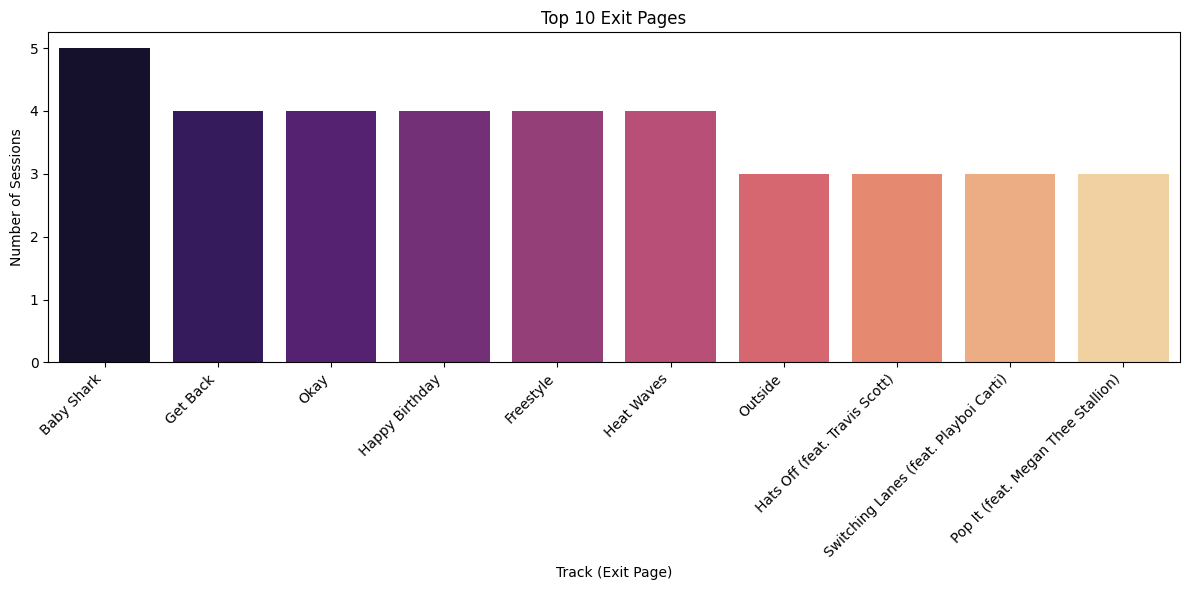

In [7]:
# Identify entry pages (first event in each session)
entry_pages = df.groupby('linkid').first()['track'].value_counts().head(10)

print("Top 10 Entry Pages:")
print(entry_pages)

# Identify exit pages (last event in each session)
exit_pages = df.groupby('linkid').last()['track'].value_counts().head(10)

print("\nTop 10 Exit Pages:")
print(exit_pages)

# Visualize top entry pages
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=entry_pages.index, y=entry_pages.values, palette='viridis')
plt.title('Top 10 Entry Pages')
plt.xlabel('Track (Entry Page)')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Visualize top exit pages
plt.figure(figsize=(12, 6))
sns.barplot(x=exit_pages.index, y=exit_pages.values, palette='magma')
plt.title('Top 10 Exit Pages')
plt.xlabel('Track (Exit Page)')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Recommendations for Conversion Optimization

Based on the analysis of traffic data, including sessions, users, bounce rate, and user flow patterns (top entry and exit pages), here are 5 recommendations to improve conversions for Alfido Tech:

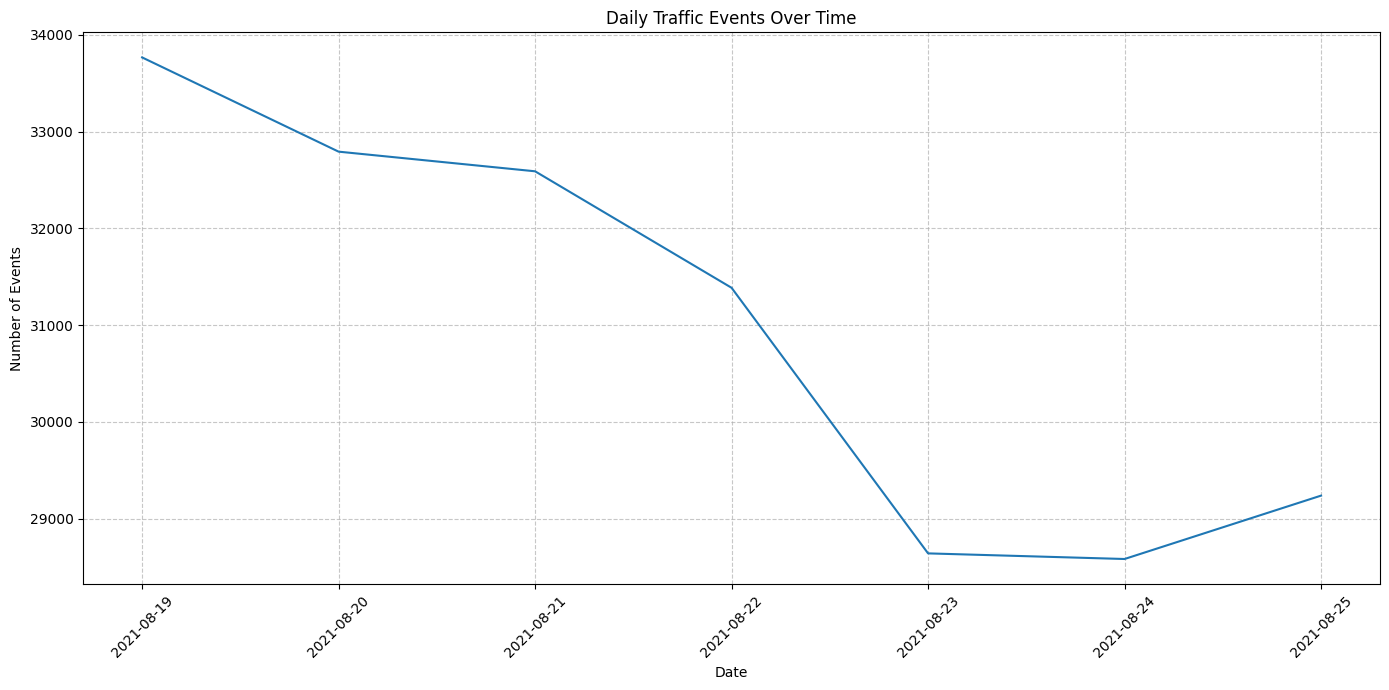

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by date and count events
daily_events = df.groupby('date')['event'].count().reset_index()
daily_events.columns = ['date', 'event_count']

# Plot the distribution of events over time
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='event_count', data=daily_events)
plt.title('Daily Traffic Events Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Events per User

To understand user engagement, let's calculate the average number of events (actions) each user performs during their sessions.

In [9]:
# Calculate the number of events per user (linkid)
events_per_user = df.groupby('linkid')['event'].count()

# Calculate the average number of events per user
average_events_per_user = events_per_user.mean()

print(f"Average number of events per user: {average_events_per_user:.2f}")

Average number of events per user: 58.01


## Average Events per User by Country

Now, let's break down the average events per user by country to see how engagement varies geographically.

In [10]:
# Calculate the number of events per user (linkid) for each country
events_per_user_per_country = df.groupby(['country', 'linkid'])['event'].count()

# Calculate the average number of events per user for each country
average_events_by_country = events_per_user_per_country.groupby('country').mean().sort_values(ascending=False)

print("Average number of events per user by country:")
print(average_events_by_country)

Average number of events per user by country:
country
Saudi Arabia    101.484375
India           101.380835
France           41.637119
Iraq             35.542601
Pakistan         23.287554
                   ...    
Macao             1.000000
Lesotho           1.000000
Sint Maarten      1.000000
Saint Martin      1.000000
Samoa             1.000000
Name: event, Length: 212, dtype: float64


## Visualizing Average Events per User Across Top 10 Countries

To better understand the geographical engagement, let's create a bar chart showing the average events per user for the top 10 countries.

/tmp/ipykernel_6682/3603350869.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')


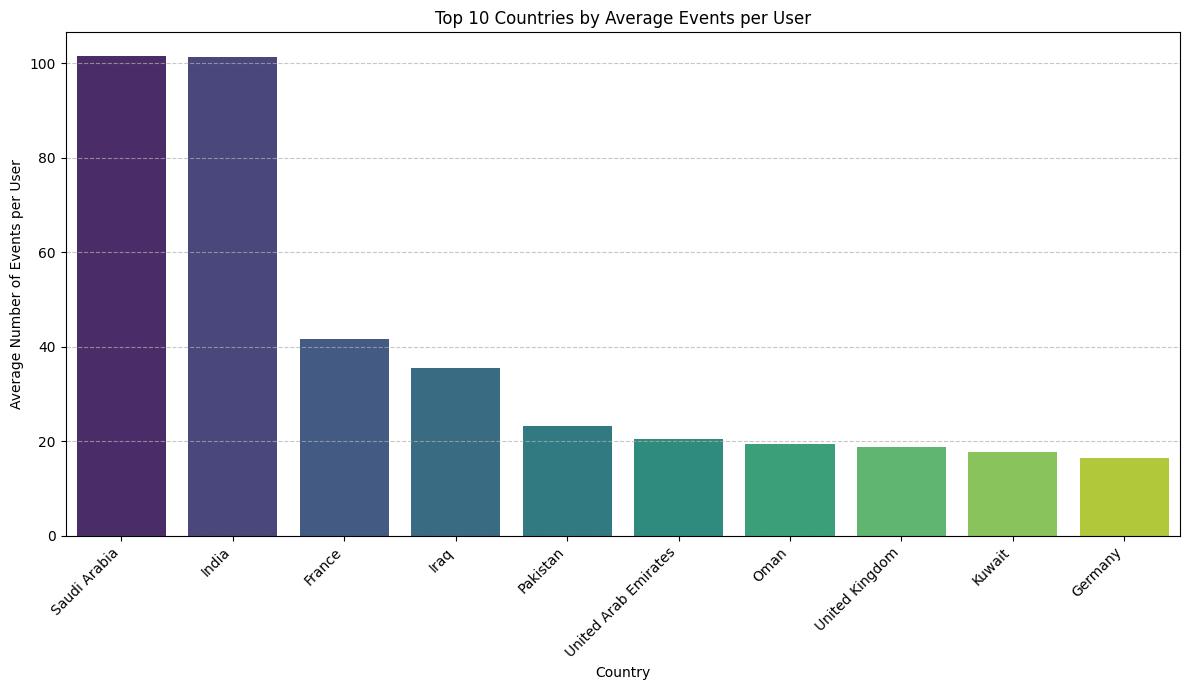

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 countries by average events per user
top_10_countries = average_events_by_country.head(10)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='viridis')
plt.title('Top 10 Countries by Average Events per User')
plt.xlabel('Country')
plt.ylabel('Average Number of Events per User')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Event Type Distribution Across Top 5 Countries

To understand the specific actions users are taking in the most engaged countries, let's visualize the distribution of event types for the top 5 countries by average events per user.

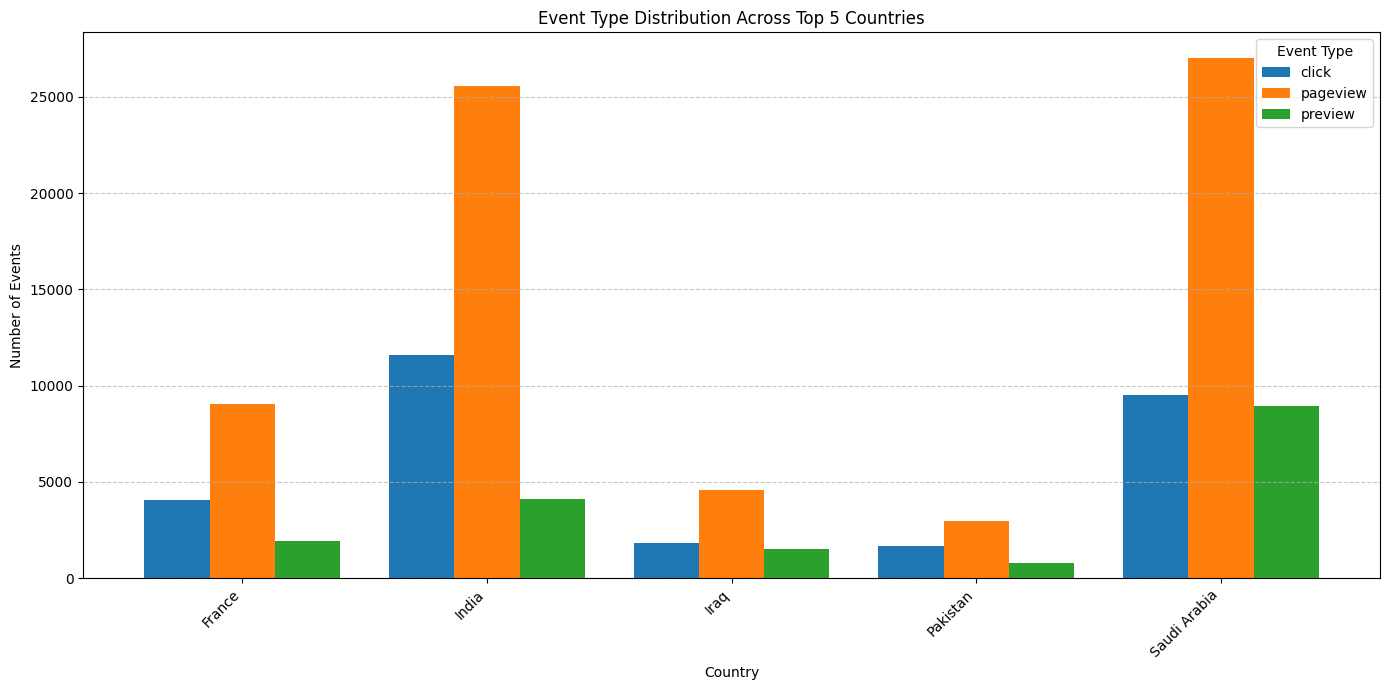

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 5 countries based on average events per user
top_5_countries = average_events_by_country.head(5).index.tolist()

# Filter the DataFrame for these top 5 countries
df_top5_countries = df[df['country'].isin(top_5_countries)]

# Group by country and event type, then count occurrences
event_type_distribution = df_top5_countries.groupby(['country', 'event']).size().unstack(fill_value=0)

# Plotting the grouped bar chart
ax = event_type_distribution.plot(kind='bar', figsize=(14, 7), width=0.8)
plt.title('Event Type Distribution Across Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Event Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Most Frequent Artist in Top 5 Countries

To further explore engagement and content preferences, let's identify the most frequently occurring artist within each of the top 5 countries.

In [13]:
# Group by country and artist, then count events for each artist
artist_counts_per_country = df_top5_countries.groupby(['country', 'artist']).size().reset_index(name='event_count')

# Find the most frequent artist for each country
most_frequent_artist = artist_counts_per_country.loc[artist_counts_per_country.groupby('country')['event_count'].idxmax()]

print("Most Frequent Artist in Top 5 Countries:")
print(most_frequent_artist)

Most Frequent Artist in Top 5 Countries:
           country  artist  event_count
254         France  Tesher         2103
602          India  Tesher         8129
833           Iraq  Tesher         3277
1028      Pakistan  Tesher         1261
1379  Saudi Arabia  Tesher        12603
